# Diversity Metrics for Synthetic EEG

This notebook illustrates three complementary **diversity domains** for evaluating synthetic EEG:

1. **Coverage diversity (manifold coverage)**  
   – Do synthetic samples cover the same regions as real data and avoid unrealistic outliers?

2. **Geometric diversity (PCA / UMAP space)**  
   – Once embedded in a low-dimensional space, do real and synthetic samples share a similar *structure* (cluster position and shape)?

3. **Intrinsic diversity (within-synthetic)**  
   – How diverse are synthetic samples among themselves, compared to real ones (mode collapse vs over-dispersion)?

For each domain we:
- briefly introduce the **metric equations**,
- build simple **2D toy scenarios**,
- and interpret the metric values together with the figures.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from diversity2 import *

sns.set(style="white", font_scale=1.2)
plt.rcParams["figure.dpi"] = 120


In [2]:
def plot_real_synth_2d(real, synth, title=""):
    """Simple helper: plot 2D real vs synthetic points."""
    real = np.asarray(real)
    synth = np.asarray(synth)
    df = pd.DataFrame(
        np.vstack([real, synth]),
        columns=["dim1", "dim2"]
    )
    df["Type"] = ["Real"] * len(real) + ["Synthetic"] * len(synth)

    plt.figure(figsize=(5, 4))
    sns.scatterplot(
        data=df, x="dim1", y="dim2", hue="Type",
        palette={"Real": "limegreen", "Synthetic": "lightskyblue"},
        edgecolor="black", s=70, alpha=0.8
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    sns.despine(left=True, bottom=True)
    plt.legend(title="", loc="best")
    plt.tight_layout()
    plt.show()


## 1. Manifold Coverage Diversity

**Goal**  
Assess whether  

- every **real** sample has a nearby **synthetic** neighbour (**coverage**), and  
- every **synthetic** sample lies close to the **real** manifold (**outlier goodness**).

Let

- ${ \{x_i\}_{i=1}^{N_r} }$ be real samples  
- ${ \{y_j\}_{j=1}^{N_s} }$ be synthetic samples  
- $ d(\cdot, \cdot) $ be the Euclidean distance  


---

### 1.1 Bandwidth \( \sigma \)

We estimate a data-driven bandwidth from real–real distances:

$$
\sigma = \operatorname{median} \{ d(x_i, x_k) : i \neq k \}.
$$

---

### 1.2 Coverage (real → synthetic)

For each real sample \( x_i \), we compute its distance to the nearest synthetic sample:

$$
d_i^{(r \to s)} = \min_{1 \le j \le N_s} d(x_i, y_j).
$$

The **coverage** score is:

$$
\mathrm{Coverage}
= \frac{1}{N_r} \sum_{i=1}^{N_r}
\exp\!\left(
- \frac{(d_i^{(r \to s)})^2}{2 \sigma^2}
\right),
\qquad \mathrm{Coverage} \in [0, 1].
$$

---

### 1.3 Outlier goodness (synthetic → real)

For each synthetic sample \( y_j \), compute its nearest real neighbour:

$$
d_j^{(s \to r)} = \min_{1 \le i \le N_r} d(y_j, x_i).
$$

The **outlier-goodness** score is:

$$
\mathrm{Outliers}
= \frac{1}{N_s} \sum_{j=1}^{N_s}
\exp\!\left(
- \frac{(d_j^{(s \to r)})^2}{2 \sigma^2}
\right),
\qquad \mathrm{Outliers} \in [0, 1].
$$

---

### 1.4 Interpretation

- **Coverage ≈ 1** → every real point is close to some synthetic point  
- **Outliers ≈ 1** → synthetic points remain close to the real manifold  
- Low values indicate:
  - missing modes  
  - synthetic drift  
  - far-out unreal points  


Scenario 1: Good coverage
[Manifold Coverage] Sigma: 2.3334
[Manifold Coverage] Coverage (real→synth): 0.995  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.994  (↑ better)


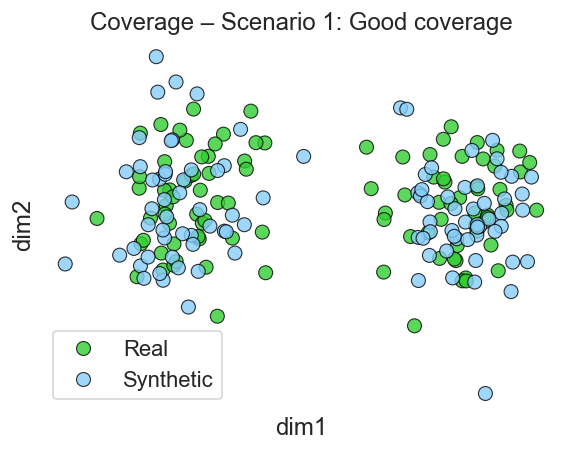

Synthetic data cover both real blobs and stay close to the manifold.

Scenario 2: Missing left mode
[Manifold Coverage] Sigma: 2.3334
[Manifold Coverage] Coverage (real→synth): 0.867  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.995  (↑ better)


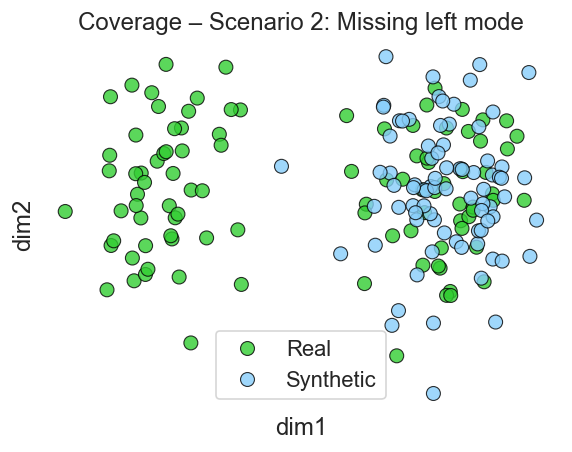

Coverage ↓ (real points in the missing blob are far from any synthetic neighbour).
Outliers can still be high (synthetic points are always near some real points).
→ Detects mode dropping (real regions with no synthetic coverage).

Scenario 3: Synthetic outlier island
[Manifold Coverage] Sigma: 2.3334
[Manifold Coverage] Coverage (real→synth): 0.994  (↑ better)
[Manifold Coverage] Outlier Goodness (synth→real): 0.827  (↑ better)


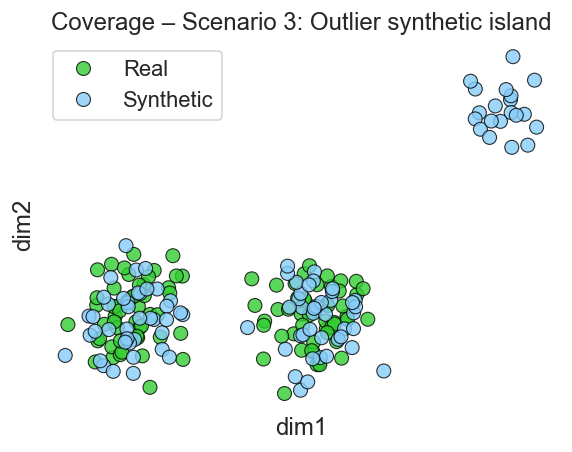

Coverage remains good around the main blobs.
Outliers ↓ because many synthetic samples are far from all real points.
→ Detects unrealistic synthetic clusters outside the real distribution.



In [12]:
rng = np.random.default_rng(0)
div = Diversity()

# Real data: two blobs (two "modes")
real_blob1 = rng.normal(loc=(-2, 0), scale=0.6, size=(50, 2))
real_blob2 = rng.normal(loc=( 2, 0), scale=0.6, size=(50, 2))
real_cov = np.vstack([real_blob1, real_blob2])

# 1) Good coverage: synthetic follows both blobs
syn_good = np.vstack([
    rng.normal(loc=(-2, 0), scale=0.6, size=(50, 2)),
    rng.normal(loc=( 2, 0), scale=0.6, size=(50, 2)),
])

print("Scenario 1: Good coverage")
cov1 = div.compute_coverage_diversity(real_cov, syn_good)
plot_real_synth_2d(real_cov, syn_good, title="Coverage – Scenario 1: Good coverage")
#print(cov1, "\n")
print("Synthetic data cover both real blobs and stay close to the manifold.")
print("")

# 2) Missing mode: synthetic covers only right blob
syn_missing = rng.normal(loc=(2, 0), scale=0.6, size=(80, 2))

print("Scenario 2: Missing left mode")
cov2 = div.compute_coverage_diversity(real_cov, syn_missing)
plot_real_synth_2d(real_cov, syn_missing, title="Coverage – Scenario 2: Missing left mode")
#print(cov2, "\n")
print("Coverage ↓ (real points in the missing blob are far from any synthetic neighbour).")
print("Outliers can still be high (synthetic points are always near some real points).") 
print("→ Detects mode dropping (real regions with no synthetic coverage).")
print("")

# 3) Outlier cluster: good main coverage + far-away synthetic island
syn_outliers_main = np.vstack([
    rng.normal(loc=(-2, 0), scale=0.6, size=(40, 2)),
    rng.normal(loc=( 2, 0), scale=0.6, size=(40, 2)),
])
syn_outlier_island = rng.normal(loc=(6, 4), scale=0.4, size=(20, 2))
syn_outliers = np.vstack([syn_outliers_main, syn_outlier_island])

print("Scenario 3: Synthetic outlier island")
cov3 = div.compute_coverage_diversity(real_cov, syn_outliers)
plot_real_synth_2d(real_cov, syn_outliers, title="Coverage – Scenario 3: Outlier synthetic island")
#print(cov3)
print("Coverage remains good around the main blobs.")
print("Outliers ↓ because many synthetic samples are far from all real points.")
print("→ Detects unrealistic synthetic clusters outside the real distribution.")
print("")


## 2. Geometric Diversity in PCA / UMAP Space

After dimensionality reduction (PCA or UMAP), we study **how real and synthetic clusters are arranged in space**.

### 2.1 Mahalanobis-based Overlap

Let:
- ${ \mu_r, \mu_s }$ be the centroids of real and synthetic embeddings  
- ${ S_r, S_s}$  the covariance matrices of each set  
- ${ S_p = S_r + S_s + \epsilon I }$ the pooled covariance  

The squared Mahalanobis distance between centroids is:
$$
d^2 = (\mu_r - \mu_s)^\top S_p^{-1} (\mu_r - \mu_s)
$$

We convert this to an **overlap score**:
$$
\text{Overlap} = \exp\left(-\frac{1}{2} d^2\right) \in (0, 1]
$$

- Overlap ≈ 1 → centroids close relative to the spread (aligned manifolds).  
- Overlap ≈ 0 → centroids far apart (shifted distributions).

### 2.2 Compactness (rescaled Silhouette score)

For each sample \( k \):

- ${ a_k }$: mean distance to points of the **same** class  
- ${ b_k }$: mean distance to the **nearest other** class  

The silhouette is:
$$
s_k = \frac{b_k - a_k}{\max(a_k, b_k)} \in [-1, 1]
$$

We compute class-wise means (real and synthetic), average them, and rescale:
$$
\bar{s} = \frac{\bar{s}_{\text{real}} + \bar{s}_{\text{syn}}}{2}, \quad
\text{Compactness} = \frac{\bar{s} + 1}{2} \in [0, 1]
$$

- Compactness ≈ 1 → each class forms a cohesive cluster, well separated from the other.  
- Compactness ≈ 0.5 → overlapping or diffuse clusters.  
- Compactness close to 0 → very poor structure.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Geometric Diversity] PCA  -> Compactness: 0.498 | Mahalanobis Overlap: 0.994
[Geometric Diversity] UMAP -> Compactness: 0.499 | Mahalanobis Overlap: 0.991


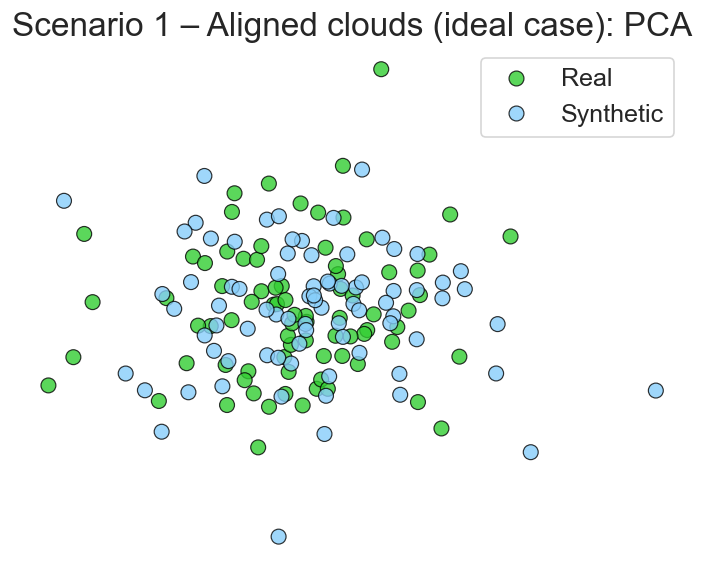

Scenario 1 – Aligned clouds (ideal case): PCA
PCA_OverlapMahalanobis: 0.9936159580180789
PCA_Compactness: 0.4978508197560258 



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Geometric Diversity] PCA  -> Compactness: 0.797 | Mahalanobis Overlap: 0.008
[Geometric Diversity] UMAP -> Compactness: 0.901 | Mahalanobis Overlap: 0.000


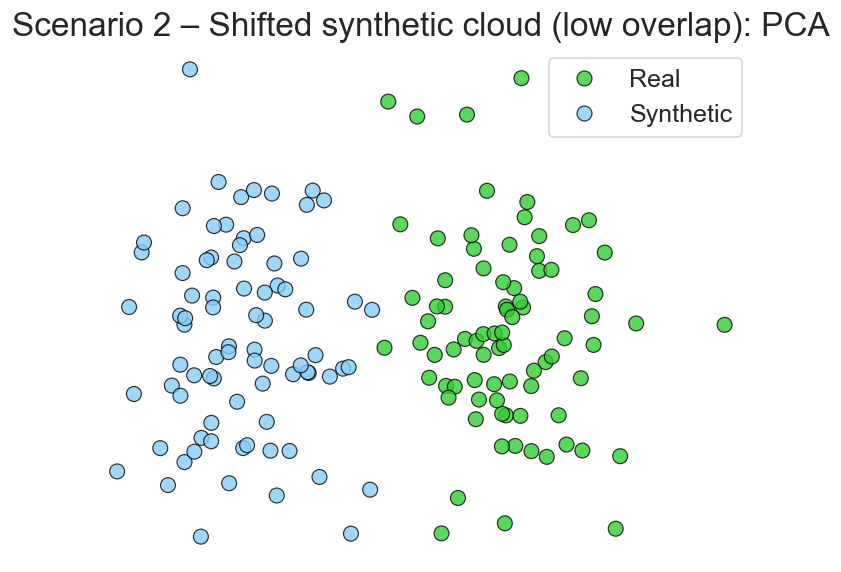

Scenario 2 – Shifted synthetic cloud (low overlap): PCA
PCA_OverlapMahalanobis: 0.007973184476440989
PCA_Compactness: 0.7965882549295296 



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Geometric Diversity] PCA  -> Compactness: 0.516 | Mahalanobis Overlap: 0.988
[Geometric Diversity] UMAP -> Compactness: 0.511 | Mahalanobis Overlap: 0.996


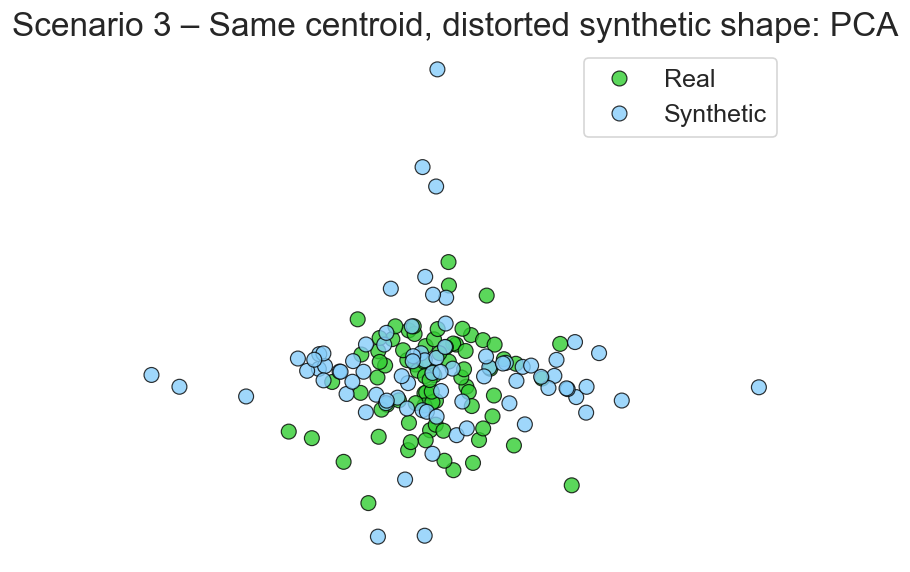

Scenario 3 – Same centroid, distorted synthetic shape: PCA
PCA_OverlapMahalanobis: 0.9883298163034439
PCA_Compactness: 0.5163292901014653 



In [5]:
div = Diversity()
rng = np.random.default_rng(1)

def run_geom_example(real, syn, title):
    geom = div.compute_geometric_diversity(real, syn)
    # Show PCA embedding as used by the metric
    div.plot_embeddings("PCA", geom, save=None, plot_title=title)
    print(title)
    print("PCA_OverlapMahalanobis:", geom["PCA_OverlapMahalanobis"])
    print("PCA_Compactness:", geom["PCA_Compactness"], "\n")
    return geom

# Base real cloud
real_geom = rng.normal(loc=(0, 0), scale=1.0, size=(80, 2))

# 1) Aligned clusters: same mean & covariance
syn_aligned = rng.normal(loc=(0, 0), scale=1.0, size=(80, 2))
geom1 = run_geom_example(real_geom, syn_aligned,
                         "Scenario 1 – Aligned clouds (ideal case): PCA")

# 2) Shifted synthetic cluster
syn_shifted = rng.normal(loc=(3, 2), scale=1.0, size=(80, 2))
geom2 = run_geom_example(real_geom, syn_shifted,
                         "Scenario 2 – Shifted synthetic cloud (low overlap): PCA")

# 3) Same centroid, different shape (distorted synthetic manifold)
syn_elong = np.vstack([
    rng.normal(loc=(0, 0), scale=(2.0, 0.3), size=(60, 2)),
    rng.normal(loc=(0, 0), scale=(0.4, 2.0), size=(20, 2)),
])
geom3 = run_geom_example(real_geom, syn_elong,
                         "Scenario 3 – Same centroid, distorted synthetic shape: PCA")


### Geometric Diversity – Interpretation

- **Scenario 1 – Aligned clouds**
  - Overlap ≈ 1  
  - Compactness high  
  → Real and synthetic occupy the same region and form clean, cohesive clusters.

- **Scenario 2 – Shifted synthetic cloud**
  - Overlap ↓ (centroids far apart in PCA space)  
  - Compactness still moderate–high (each class internally well-formed)  
  → Good internal structure but **geometric shift** between real and synthetic manifolds.

- **Scenario 3 – Same centroid, different shape**
  - Overlap relatively high (centroids coincide thanks to same mean)  
  - Compactness ↓ (synthetic cluster elongated and messy)  
  → Centroids aligned, but **local geometry and cluster shape are not preserved**.

Overlap and Compactness are therefore **complementary**:
- Overlap reflects *where* the clouds live.  
- Compactness reflects *how* each cloud is internally organised relative to the other.


## 3. Intrinsic Diversity – Uniqueness & Local/Global Ratios

Here we compare **within-set distances** in synthetic vs real data.

Let  ${D^{\text{NN}}_{\text{real}}}$ be the vector of nearest-neighbour distances within the real set, and similarly ${ D^{\text{NN}}_{\text{syn}} }$ for the synthetic set.

We compute:

- Mean NN distances:
$$
\bar{d}^{\text{NN}}_{\text{real}} = \mathrm{mean}(D^{\text{NN}}_{\text{real}}),
\quad
\bar{d}^{\text{NN}}_{\text{syn}}   = \mathrm{mean}(D^{\text{NN}}_{\text{syn}})
$$

- Percentiles of NN distances (10th and 50th):
$$
P_{10}^{\text{real}}, P_{50}^{\text{real}}, 
\quad
P_{10}^{\text{syn}}, P_{50}^{\text{syn}}
$$

- Mean pairwise distances (optionally with subsampling):
$$
\bar{d}^{\text{PW}}_{\text{real}}, \quad
\bar{d}^{\text{PW}}_{\text{syn}}
$$

Then the intrinsic diversity metrics are **ratios (synthetic / real)**:

- **Uniqueness** (mean NN distance ratio):
$$
\text{Uniqueness NN} = \frac{\bar{d}^{\text{NN}}_{\text{syn}}}{\bar{d}^{\text{NN}}_{\text{real}}}
$$

- **Global diversity**:
$$
\text{Global Diversity} = 
\frac{\bar{d}^{\text{PW}}_{\text{syn}}}{\bar{d}^{\text{PW}}_{\text{real}}}
$$

- **Local diversity (P10 / P50)**:
$$
\text{Local Diversity P10} = \frac{P_{10}^{\text{syn}}}{P_{10}^{\text{real}}},
\quad
\text{Local Diversity P50} = \frac{P_{50}^{\text{syn}}}{P_{50}^{\text{real}}}
$$

Interpretation:

- $≈$ 1 → synthetic variability matches real variability.  
- $<$ 1 → **mode collapse** (synthetic points too close to each other).  
- $>$ 1 → **over-dispersion** (synthetic points too spread out).


=== Intrinsic Scenario 1: Real-like diversity ===


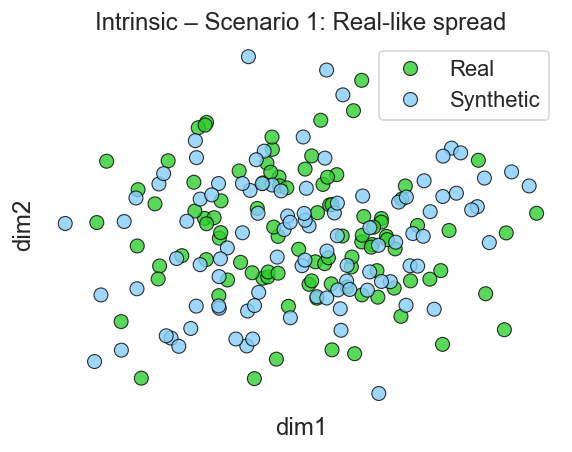

[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 0.963  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 1.095
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 1.636 / 0.991
{'Uniqueness_NN': 0.9628786880525835, 'Global_Diversity': 1.0949101508520807, 'Local_Diversity_P10': 1.635747482524551, 'Local_Diversity_P50': 0.9907264608366371} 

=== Intrinsic Scenario 2: Mode collapse ===


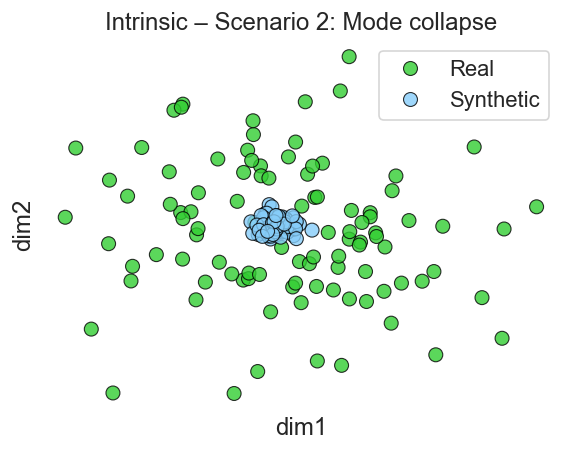

[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 0.095  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 0.100
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 0.110 / 0.082
{'Uniqueness_NN': 0.09529462164042335, 'Global_Diversity': 0.0998760335044164, 'Local_Diversity_P10': 0.10993332735630557, 'Local_Diversity_P50': 0.0819439058833752} 

=== Intrinsic Scenario 3: Over-dispersion ===


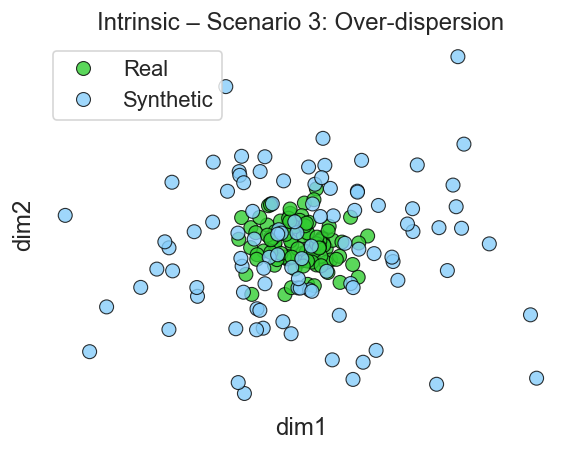

[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 3.479  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 3.191
[Intrinsic Diversity] Local Diversity P10 / P50 (NN ratio): 2.887 / 3.307
{'Uniqueness_NN': 3.47868079220157, 'Global_Diversity': 3.1912386321692305, 'Local_Diversity_P10': 2.8872024748947838, 'Local_Diversity_P50': 3.3073111981350714}


In [5]:
div = Diversity()
rng = np.random.default_rng(2)

# Real baseline cloud
real_intr = rng.normal(loc=(0, 0), scale=1.0, size=(100, 2))

# 1) Real-like synthetic diversity
syn_like = rng.normal(loc=(0, 0), scale=1.0, size=(100, 2))
print("=== Intrinsic Scenario 1: Real-like diversity ===")
plot_real_synth_2d(real_intr, syn_like, "Intrinsic – Scenario 1: Real-like spread")
intr1 = div.compute_intrinsic_diversity(real_intr, syn_like)
print(intr1, "\n")

# 2) Mode collapse: synthetic samples highly concentrated
syn_collapse = rng.normal(loc=(0, 0), scale=0.1, size=(100, 2))
print("=== Intrinsic Scenario 2: Mode collapse ===")
plot_real_synth_2d(real_intr, syn_collapse, "Intrinsic – Scenario 2: Mode collapse")
intr2 = div.compute_intrinsic_diversity(real_intr, syn_collapse)
print(intr2, "\n")

# 3) Over-dispersion: synthetic cloud much more spread
syn_over = rng.normal(loc=(0, 0), scale=3.0, size=(100, 2))
print("=== Intrinsic Scenario 3: Over-dispersion ===")
plot_real_synth_2d(real_intr, syn_over, "Intrinsic – Scenario 3: Over-dispersion")
intr3 = div.compute_intrinsic_diversity(real_intr, syn_over)
print(intr3)


### Intrinsic Diversity – Interpretation

- **Scenario 1 – Real-like diversity**
  - Uniqueness NN ≈ 1  
  - Global Diversity ≈ 1  
  - Local Diversity_P10 / P50 ≈ 1  
  → Synthetic spread is very similar to real: **good intrinsic diversity**.

- **Scenario 2 – Mode collapse**
  - Uniqueness NN ≪ 1 (synthetic NN distances very small)  
  - Global Diversity ≪ 1  
  - Local Diversity_P10 / P50 especially small  
  → Strong evidence of **mode collapse** (many nearly identical samples).

- **Scenario 3 – Over-dispersion**
  - Uniqueness NN > 1  
  - Global Diversity > 1  
  - Local Diversity_P10 / P50 > 1  
  → Synthetic samples are **too spread**, potentially exploring unrealistic regions.

These metrics generalise ideas like synthetic-to-synthetic similarity and intra-class distances by directly comparing distance statistics in synthetic vs real sets.


## Summary

- **Coverage diversity (Coverage + Outliers)**  
  Ensures that synthetic EEG signals **reach all regions** of the real distribution while **avoiding unrealistic outliers**.

- **Geometric diversity (Overlap + Compactness)**  
  Evaluates whether real and synthetic data share a similar **geometric structure** in PCA/UMAP space:
  - Overlap → how aligned the centroids are (after normalising by covariance).  
  - Compactness → how cohesive and well-separated the real vs synthetic clusters are (rescaled silhouette).

- **Intrinsic diversity (Uniqueness, Global, Local)**  
  Measures how diverse the synthetic dataset is **by itself**, relative to real:
  - detects **mode collapse** (ratios $<$ 1)  
  - and **over-dispersion** (ratios $>$ 1).

Together, these three domains offer a richer and more interpretable assessment of synthetic EEG diversity than any single metric in isolation.
